In [2]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)



True

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 上下文保存：文件系统

<img src="./resources/agent_header_files.png" width="800" style="display:block; margin-left:0;">

在复杂任务中，智能体的上下文窗口会快速增长——Manus 的平均任务大约使用 50 次工具调用，造成了大量的上下文累积。管理这种增长的一个强大技术是通过文件系统操作进行**上下文卸载**。智能体可以将信息策略性地保存到文件中，并在[需要时获取](https://blog.langchain.com/context-engineering-for-agents/)，而不是将所有工具调用观察和中间结果直接存储在上下文窗口中，从而保持专注的同时保留对关键信息的访问。

这种方法已被 [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) 和 [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research) 等生产系统成功实施。Anthropic 的[多智能体研究系统](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Subagent%20output%20to%20a%20filesystem%20to%20minimize%20the%20%E2%80%98game%20of%20telephone.%E2%80%99)提供了另一个引人注目的例子，其中子智能体将其工作存储在外部系统中，并将轻量级引用返回给协调器。这防止了"传话游戏"效应——信息在通过多个智能体传递时的退化——同时使新的子智能体能够以干净的上下文启动，并在需要时从内存中检索存储的上下文（如研究计划）。

通过在沙盒环境中将高 token 消耗的上下文写入文件，智能体可以有效地管理内存，同时保持检索详细信息的能力。这种模式对于结构化输出（如代码、报告或数据可视化）特别有价值，其中专门的提示比通过通用协调器过滤产生更好的结果，也适用于需要保存中间结果但不需要持续关注的长期研究任务。


### 文件工具

我们的实现使用虚拟文件系统方法，在 LangGraph 状态中模拟传统文件系统。核心思路是使用一个简单的字典，其中键代表模拟文件路径，值包含文件内容。这种方法提供了短期的、线程级别的持久化，非常适合在单个智能体会话中维护上下文，但不适用于需要在不同会话线程之间持久化的信息。文件操作利用 LangGraph 的 `Command` 类型来更新智能体状态，使工具能够修改虚拟文件系统并在智能体执行过程中维护适当的状态管理。

你将构建三个文件工具——`ls`、`read_file` 和 `write_file`——它们在虚拟文件系统上运行。

**用法：**
- 当 LLM 的上下文中有想要持久化的信息时，它使用 `write_file` 将其写入文件；之后，同一个智能体或子智能体可以使用 `read_file` 检索它。
- 工具调用可以将数据写入文件，并在工具调用返回消息中向 LLM 提供文件名。LLM 随后可以决定读取部分或全部内容，或者可以应用另一个工具来处理数据。
- 使用 `ls` 列出可用文件。

读/写工具期望使用换行符分隔的纯文本（使用 `str.splitlines()` 解析）。

以下提示中的描述详细说明了它们的运作方式：


<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>注意：</b>  
<code>create_react_agent</code> 已从 LangGraph 库移至 LangChain 库，并在 1.0 代码发布后（拍摄完成后）重命名为 <code>create_agent</code>。为此，导入和代码有细微更改。视频可能显示之前的配置。
</div>

In [4]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)

show_prompt(LS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  List all files in the virtual filesystem stored in agent state.                                                │
│                                                                                                                 │
│  Shows what files currently exist in agent memory. Use this to orient yourself before other file operations     │
│  and maintain awareness of your file organization.                                                              │
│                                                                                                                 │
│  No parameters required - simply call ls() to see all available files.                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

列出智能体状态中存储的虚拟文件系统中的所有文件。

显示智能体内存中当前存在的文件。在进行其他文件操作之前使用此工具来了解方向，并保持对文件组织的认识。

无需任何参数——只需调用 `ls()` 即可查看所有可用文件。

In [5]:
show_prompt(READ_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Read content from a file in the virtual filesystem with optional pagination.                                   │
│                                                                                                                 │
│  This tool returns file content with line numbers (like `cat -n`) and supports reading large files in chunks    │
│  to avoid context overflow.                                                                                     │
│                                                                                                                 │
│  Parameters:                                                                                                    │
│  - file_path (required): Path to the file you want to read. **CRITICAL: The parameter name MUST be              │
│  "file_path", NOT "file".**                                                                                     │
│  - offset (optional, default=0): Line number to start reading from                                              │
│  - limit (optional, default=2000): Maximum number of lines to read                                              │
│                                                                                                                 │
│  **IMPORTANT**: When calling this tool, use the parameter name "file_path" exactly as shown. Do NOT use "file"  │
│  or any other variation.                                                                                        │
│                                                                                                                 │
│  Essential before making any edits to understand existing content. Always read a file before editing it.        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

从虚拟文件系统中读取文件内容，支持可选的分页功能。

此工具返回带有行号的内容（类似于 `cat -n`），并支持分块读取大文件以避免上下文溢出。

**参数：**
- `file_path`（必填）：要读取的文件路径。**关键：参数名称必须为 "file_path"，而不是 "file"。**
- `offset`（可选，默认值=0）：开始读取的行号
- `limit`（可选，默认值=2000）：要读取的最大行数

**重要提示**：调用此工具时，请务必使用参数名称 "file_path"。不要使用 "file" 或任何其他变体。

在编辑任何文件之前，必须先阅读文件内容以了解现有内容。始终在编辑之前先读取文件。

In [6]:
show_prompt(WRITE_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Create a new file or completely overwrite an existing file in the virtual filesystem.                          │
│                                                                                                                 │
│  This tool creates new files or replaces entire file contents. Use for initial file creation or complete        │
│  rewrites. Files are stored persistently in agent state.                                                        │
│                                                                                                                 │
│  Parameters:                                                                                                    │
│  - file_path (required): Path where the file should be created/overwritten                                      │
│  - content (required): The complete content to write to the file                                                │
│                                                                                                                 │
│  Important: This replaces the entire file content.                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

在虚拟文件系统中创建新文件或完全覆盖现有文件。

此工具用于创建新文件或替换整个文件内容。适用于初始文件创建或完全重写。文件永久存储在智能体状态中。

**参数：**
- `file_path`（必填）：要创建/覆盖的文件路径
- `content`（必填）：要写入文件的完整内容

**重要提示**：这会替换整个文件内容。

让我们在下面实现这些函数。有两点值得注意。第一是使用 `@tool(description=PROMPT)`。请注意，当工具装饰器中有 `description="xyz"` 时，"xyz" 会被发送给 LLM，而 docstring 会被抑制。将冗长的描述放在单独的 prompts 文件中通常更方便。这为解释工具的操作方式以及如何在此应用中使用它提供了空间。第二点是错误消息。这些消息是面向 LLM 而非人类用户的。在智能体系统中，LLM 可以利用错误消息中的信息来重试操作。


In [7]:
%%writefile ../../src/deep_agents_from_scratch/file_tools.py
"""Virtual file system tools for agent state management.

This module provides tools for managing a virtual filesystem stored in agent state,
enabling context offloading and information persistence across agent interactions.
"""

from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)
from deep_agents_from_scratch.state import DeepAgentState


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """List all files in the virtual filesystem."""
    return list(state.get("files", {}).keys())


@tool(description=READ_FILE_DESCRIPTION, parse_docstring=True)
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """Read file content from virtual filesystem with optional offset and limit.

    Args:
        file_path: Path to the file to read
        state: Agent state containing virtual filesystem (injected in tool node)
        offset: Line number to start reading from (default: 0)
        limit: Maximum number of lines to read (default: 2000)

    Returns:
        Formatted file content with line numbers, or error message if file not found
    """
    files = state.get("files", {})
    if file_path not in files:
        return f"Error: File '{file_path}' not found"

    content = files[file_path]
    if not content:
        return "System reminder: File exists but has empty contents"

    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    if start_idx >= len(lines):
        return f"Error: Line offset {offset} exceeds file length ({len(lines)} lines)"

    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # Truncate long lines
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION, parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Write content to a file in the virtual filesystem.

    Args:
        file_path: Path where the file should be created/updated
        content: Content to write to the file
        state: Agent state containing virtual filesystem (injected in tool node)
        tool_call_id: Tool call identifier for message response (injected in tool node)

    Returns:
        Command to update agent state with new file content
    """
    files = state.get("files", {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(f"Updated file {file_path}", tool_call_id=tool_call_id)
            ],
        }
    )

Overwriting ../../src/deep_agents_from_scratch/file_tools.py


# 重新审视状态和归约器
在之前的笔记本中，我们定义了文件状态和归约器，但没有对它们进行描述。让我们在这里完成这项工作。
在 `DeepAgentState` 中，`files` 被定义为一个包含键和值的字典。如上所述，键是文件名，值是文件内容。当执行 `write_files` 中的 `Command` 时，`files` 会通过 `file_reducer` 被添加到状态中。在这个归约器中，`left` 是状态中已有的文件，`right` 是新的值。最后的语句允许新值覆盖旧值：`{**left, **right}`，Python 首先解包 `left`，然后解包 `right`。`right` 中的任何重复键都会覆盖来自 `left` 的先前值。
```python
def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """

    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
```

我们有一个虚拟文件系统和与之配合的工具。让我们构建一个简单的研究代理来试用它。
该代理将存储用户的请求，然后在回答用户问题之前将其读取回来！

请注意，这种简单的方法[对于长时间运行的代理轨迹非常有用](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)！在这个简单的例子中，所有信息都可以轻松保存在上下文中，但对于长时间运行的代理，上下文内容可能会被压缩或消除。在压缩之前存储信息并在需要时检索它是智能的上下文工程。


In [9]:
# File usage instructions
FILE_USAGE_INSTRUCTIONS = """You have access to a virtual file system to help you retain and save context.                                  

                                                                                                                

## Workflow Process (FOLLOW IN ORDER):                                                                                            

1. **FIRST ACTION REQUIRED**: Before doing anything else, you MUST call the write_file tool with file_path="user_request.txt" and content=<the user's exact request>. This is MANDATORY - do not proceed without calling write_file first.                                             

2. **Orient**: Use the ls tool to see existing files                                             

3. **Research**: Make a single call to the web_search tool and use the result provided by the tool to answer the user's question.

4. **Read**: Once you are satisfied with the collected sources, read the saved file using the read_file tool and use it to ensure that you directly answer the user's question.

5. **FINAL ACTION REQUIRED**: After formulating your complete answer, you MUST call the write_file tool with file_path="final_answer.txt" and content=<your complete answer>. This is MANDATORY - do not finish without calling write_file for the final answer.



CRITICAL: 
- Your FIRST tool call MUST be write_file with file_path="user_request.txt". Do not call any other tools until you have called write_file. Do not skip this step.
- Your LAST tool call (before responding to the user) MUST be write_file with file_path="final_answer.txt" to save your final answer. Do not skip this step."""

# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the user's question."""

# Full prompt
INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS
)
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│  ## Workflow Process (FOLLOW IN ORDER):                                                                         │
│                                                                                                                 │
│  1. **FIRST ACTION REQUIRED**: Before doing anything else, you MUST call the write_file tool with               │
│  file_path="user_request.txt" and content=<the user's exact request>. This is MANDATORY - do not proceed        │
│  without calling write_file first.                                                                              │
│                                                                                                                 │
│  2. **Orient**: Use the ls tool to see existing files                                                           │
│                                                                                                                 │
│  3. **Research**: Make a single call to the web_search tool and use the result provided by the tool to answer   │
│  the user's question.                                                                                           │
│                                                                                                                 │
│  4. **Read**: Once you are satisfied with the collected sources, read the saved file using the read_file tool   │
│  and use it to ensure that you directly answer the user's question.                                             │
│                                                                                                                 │
│  5. **FINAL ACTION REQUIRED**: After formulating your complete answer, you MUST call the write_file tool with   │
│  file_path="final_answer.txt" and content=<your complete answer>. This is MANDATORY - do not finish without     │
│  calling write_file for the final answer.                                                                       │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│  CRITICAL:                                                                                                      │
│  - Your FIRST tool call MUST be write_file with file_path="user_request.txt". Do not call any other tools       │
│  until you have called write_file. Do not skip this step.                                                       │
│  - Your LAST tool call (before responding to the user) MUST be write_file with file_path="final_answer.txt" to  │
│  save your final answer. Do not skip this step.                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  IMPORTANT: Just make a single call to the web_search 


你可使用虚拟文件系统来留存并保存上下文信息。

## 工作流程（**必须按顺序执行**）：
1. **首要必执行操作**：开展任何工作前，你**必须**先调用文件写入工具，文件路径设为`user_request.txt`，文件内容填写用户的原始请求。此步骤为硬性要求，未完成该操作不得继续后续流程。
2. **查看目录**：使用列表工具查看现有文件。
3. **信息检索**：调用一次网页搜索工具，并依据工具返回结果解答用户问题。
4. **读取文件**：完成信息搜集后，使用文件读取工具读取已保存的文件，据此确保准确回应用户的问题。
5. **最终必执行操作**：整理出完整答案后，你**必须**再次调用文件写入工具，文件路径设为`final_answer.txt`，文件内容填写你的完整答案。此步骤为硬性要求，未完成该操作不得结束任务。

### 重要须知：
- 你的**首个工具调用**必须是写入`user_request.txt`文件。在完成该操作前，不得调用其他任何工具，严禁跳过此步骤。
- 向用户回复内容前，你的**最后一个工具调用**必须是写入`final_answer.txt`文件以保存最终答案，严禁跳过此步骤。

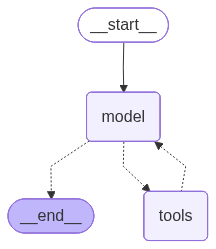

In [10]:
from IPython.display import Image, display
import os
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import format_messages

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.state import DeepAgentState

# Mock search result
search_result = """模型上下文协议（MCP）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI 助手连接到外部服务的过程。"""


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Create agent using create_agent directly
model = init_chat_model(
    # model="deepseek-chat",  # Qwen3 30B via Ollama (previously: x-ai/grok-4.1-fast via OpenRouter)
    model="agnes-2.0-flash",
    model_provider="openai",
    base_url=os.getenv("AGNES_BASE_URL"),
    api_key=os.getenv("AGNES_API_KEY"),
    temperature=0.0,
)
tools = [write_file, ls, read_file, web_search]  # write_file first to emphasize it's required

# Create agent with system prompt
agent = create_agent(
    model, tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Start the graph with no `files` in state and an user research request. 

In [11]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "请给我一个关于 MCP 的简短摘要。.",
            }
        ],
        "files": {},
    }
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请给我一个关于 MCP 的简短摘要。.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "user_request.txt",                                                                              │
│   "content": "请给我一个关于 MCP 的简短摘要。"                                                                  │
│ }                                                                                                               │
│    ID: chatcmpl-tool-994f5ec4871cee51                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file user_request.txt                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "MCP Model Context Protocol summary"                                                                 │
│ }                                                                                                               │
│    ID: chatcmpl-tool-98d4c88f5ace6b13                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 模型上下文协议（MCP）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI                                         │
│ 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI                           │
│ 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI   │
│ 助手连接到外部服务的过程。                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "user_request.txt"                                                                               │
│ }                                                                                                               │
│    ID: chatcmpl-tool-8346ea9b76b48a0b                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  请给我一个关于 MCP 的简短摘要。                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "content": "模型上下文协议（MCP，Model Context Protocol）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI   │
│ 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI                           │
│ 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI   │
│ 助手连接到外部服务的过程。",                                                                                    │
│   "file_path": "final_answer.txt"                                                                               │
│ }                                                                                                               │
│    ID: chatcmpl-tool-9521bd1db226e930                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file final_answer.txt                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 模型上下文协议（MCP，Model Context Protocol）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI                 │
│ 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI                           │
│ 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI   │
│ 助手连接到外部服务的过程。                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

We can see the file saved in our mock file system. 

In [12]:
result["files"]

{'user_request.txt': '请给我一个关于 MCP 的简短摘要。',
 'final_answer.txt': '模型上下文协议（MCP，Model Context Protocol）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI 助手连接到外部服务的过程。'}

In [13]:
result['files']['final_answer.txt']

'模型上下文协议（MCP，Model Context Protocol）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI 助手连接到外部服务的过程。'

Trace: 
https://smith.langchain.com/public/b03e20b4-e908-488d-84a9-8f891d17addd/r
<!-- https://smith.langchain.com/public/1066102f-d7b3-423c-b556-006865a1d479/r -->

In [14]:
from pprint import pprint

# Display all files
print("Files in virtual filesystem:")
pprint(result["files"])

# Display the final answer if it exists
if 'final_answer.txt' in result["files"]:
    print("\n" + "="*80)
    print("Final Answer:")
    print("="*80)
    print(result["files"]['final_answer.txt'])
else:
    print("\nNote: 'final_answer.txt' not found. Available files:", list(result["files"].keys()))

Files in virtual filesystem:
{'final_answer.txt': '模型上下文协议（MCP，Model Context Protocol）是由 Anthropic '
                     '开发的一种开放标准协议，旨在实现 AI '
                     '模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI '
                     '模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 '
                     'AI 助手连接到外部服务的过程。',
 'user_request.txt': '请给我一个关于 MCP 的简短摘要。'}

Final Answer:
模型上下文协议（MCP，Model Context Protocol）是由 Anthropic 开发的一种开放标准协议，旨在实现 AI 模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使 AI 模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP 通过为数据交换提供统一的语言，简化了将 AI 助手连接到外部服务的过程。
